<a href="https://colab.research.google.com/github/IraitzSantafosta/Retrieval-Augmented-Generation/blob/main/Retrieval_Augmented_Generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Retrieval-Augmented Generation

##Dataset-a kargatu



In [ ]:
from datasets import load_dataset
import pandas as pd

# Cargar el dataset
dataset = load_dataset("lavita/MedQuAD", split="train")

# Ver las claves (columnas) que tiene
print(dataset.column_names)

# Convertir a DataFrame
df = dataset.to_pandas()

# Mostrar las primeras filas para inspeccionar
df.head()



/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/2.77k [00:00<?, ?B/s]

(…)-00000-of-00001-e36383d177026d53.parquet:   0%|          | 0.00/10.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/47441 [00:00<?, ? examples/s]

['document_id', 'document_source', 'document_url', 'category', 'umls_cui', 'umls_semantic_types', 'umls_semantic_group', 'synonyms', 'question_id', 'question_focus', 'question_type', 'question', 'answer']


,document_id,document_source,document_url,category,umls_cui,umls_semantic_types,umls_semantic_group,synonyms,question_id,question_focus,question_type,question,answer
0,0000559,GHR,https://ghr.nlm.nih.gov/condition/keratoderma-...,None,C0343073,T047,Disorders,KWWH,0000559-1,keratoderma with woolly hair,information,What is (are) keratoderma with woolly hair ?,Keratoderma with woolly hair is a group of rel...
1,0000559,GHR,https://ghr.nlm.nih.gov/condition/keratoderma-...,None,C0343073,T047,Disorders,KWWH,0000559-2,keratoderma with woolly hair,frequency,How many people are affected by keratoderma wi...,Keratoderma with woolly hair is rare; its prev...
2,0000559,GHR,https://ghr.nlm.nih.gov/condition/keratoderma-...,None,C0343073,T047,Disorders,KWWH,0000559-3,keratoderma with woolly hair,genetic changes,What are the genetic changes related to kerato...,"Mutations in the JUP, DSP, DSC2, and KANK2 gen..."
3,0000559,GHR,https://ghr.nlm.nih.gov/condition/keratoderma-...,None,C0343073,T047,Disorders,KWWH,0000559-4,keratoderma with woolly hair,inheritance,Is keratoderma with woolly hair inherited ?,Most cases of keratoderma with woolly hair hav...
4,0000559,GHR,https://ghr.nlm.nih.gov/condition/keratoderma-...,None,C0343073,T047,Disorders,KWWH,0000559-5,keratoderma with woolly hair,treatment,What are the treatments for keratoderma with w...,These resources address the diagnosis or manag...


In [ ]:
import nltk
import re
from nltk.tokenize import word_tokenize
from datasets import load_dataset
import pandas as pd
from rank_bm25 import BM25Okapi

nltk.download("punkt")
nltk.download('punkt_tab')

# Cargar dataset
dataset = load_dataset("lavita/MedQuAD", split="train")
df = dataset.to_pandas()

# Limpiar texto
def clean_text(text):
    if text is None:
        return ""  # Reemplazar valores nulos con texto vacío
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^a-zA-Z0-9.,;:!?() ]', '', text)
    return text.strip().lower()

# Preprocesar y tokenizar
df["clean_text"] = df["answer"].apply(clean_text)
df["tokens"] = df["clean_text"].apply(word_tokenize)

docs = df.head(1000)
tokenized_corpus = docs["tokens"].tolist()

# Crear índice BM25
bm25 = BM25Okapi(tokenized_corpus)

print("✅ Índice BM25 creado con", len(tokenized_corpus), "documentos.")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


✅ Índice BM25 creado con 1000 documentos.


In [ ]:
import pickle

# Guardar BM25
with open("bm25_index.pkl", "wb") as f:
    pickle.dump(bm25, f)

# Guardar dataframe preprocesado
df.to_pickle("medquad_preprocessed.pkl")

In [ ]:
# Ejemplo de una pregunta para probar la recuperación
query = "What is hypertension treatment?"
query_tokens = word_tokenize(clean_text(query))  # Limpiar y tokenizar la pregunta

# Recuperar los documentos más relevantes usando BM25
scores = bm25.get_scores(query_tokens)

# Mostrar los 5 documentos con mayor puntuación
top_docs_indices = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:5]

# Mostrar las preguntas y respuestas de los 5 documentos más relevantes
for idx in top_docs_indices:
    print(f"Document ID: {docs.iloc[idx]['document_id']}")
    print(f"Answer: {docs.iloc[idx]['answer']}")
    print(f"Score: {scores[idx]}")
    print("="*50)


Document ID: 0000990
Answer: These resources address the diagnosis or management of trichohepatoenteric syndrome:  - American Society for Parenteral and Enteral Nutrition: What is Parenteral Nutrition?  - Genetic Testing Registry: Trichohepatoenteric syndrome  - Genetic Testing Registry: Trichohepatoenteric syndrome 2  - MedlinePlus Health Topic: Nutritional Support   These resources from MedlinePlus offer information about the diagnosis and management of various health conditions:  - Diagnostic Tests  - Drug Therapy  - Surgery and Rehabilitation  - Genetic Counseling   - Palliative Care
Score: 13.507415934233762
Document ID: 0000968
Answer: These resources address the diagnosis or management of T-cell immunodeficiency, congenital alopecia, and nail dystrophy:  - Be The Match: What is a Bone Marrow Transplant?  - Genetic Testing Registry: T-cell immunodeficiency, congenital alopecia and nail dystrophy  - MedlinePlus Encyclopedia: Bone Marrow Transplant   These resources from MedlinePlu

In [ ]:
from sentence_transformers import SentenceTransformer, util

# Cargar modelo de embeddings densos
dense_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# Codificar respuestas para retrieval denso
dense_corpus = docs["clean_text"].tolist()
dense_embeddings = dense_model.encode(dense_corpus, convert_to_tensor=True)

# Función híbrida: BM25 + Dense Retrieval
def hybrid_retrieve(query, top_k=5, alpha=0.5):
    clean_query = clean_text(query)
    tokenized_query = word_tokenize(clean_query)

    bm25_scores = bm25.get_scores(tokenized_query)
    query_embedding = dense_model.encode(clean_query, convert_to_tensor=True)
    dense_scores = util.cos_sim(query_embedding, dense_embeddings)[0].tolist()

    bm25_scores = [(s - min(bm25_scores)) / (max(bm25_scores) - min(bm25_scores) + 1e-8) for s in bm25_scores]
    dense_scores = [(s - min(dense_scores)) / (max(dense_scores) - min(dense_scores) + 1e-8) for s in dense_scores]

    combined_scores = [(alpha * bm + (1 - alpha) * de) for bm, de in zip(bm25_scores, dense_scores)]
    top_indices = sorted(range(len(combined_scores)), key=lambda i: combined_scores[i], reverse=True)[:top_k]

    results = []
    for i in top_indices:
        result = {
            "question_id": docs.iloc[i]["question_id"],
            "answer": docs.iloc[i]["answer"],
            "score": combined_scores[i]
        }
        results.append(result)

    return results



modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
import torch
torch.save(dense_embeddings, 'dense_embeddings.pth')  # Guardar embeddings


In [ ]:
loaded_embeddings = torch.load('dense_embeddings.pth')  # Cargar embeddings

NO EJECUTARRRR


  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=bf1cdcdc07520df85de04368abe330564fba5aa1b4244f4b20196e60eba319a4
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge-score
Buscando para alpha = 0.0
Buscando para alpha = 0.1
Buscando para alpha = 0.2


/usr/local/lib/python3.11/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.11/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.11/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

Buscando para alpha = 0.30000000000000004
Buscando para alpha = 0.4
Buscando para alpha = 0.5
Buscando para alpha = 0.6000000000000001
Buscando para alpha = 0.7000000000000001
Buscando para alpha = 0.8
Buscando para alpha = 0.9
Buscando para alpha = 1.0


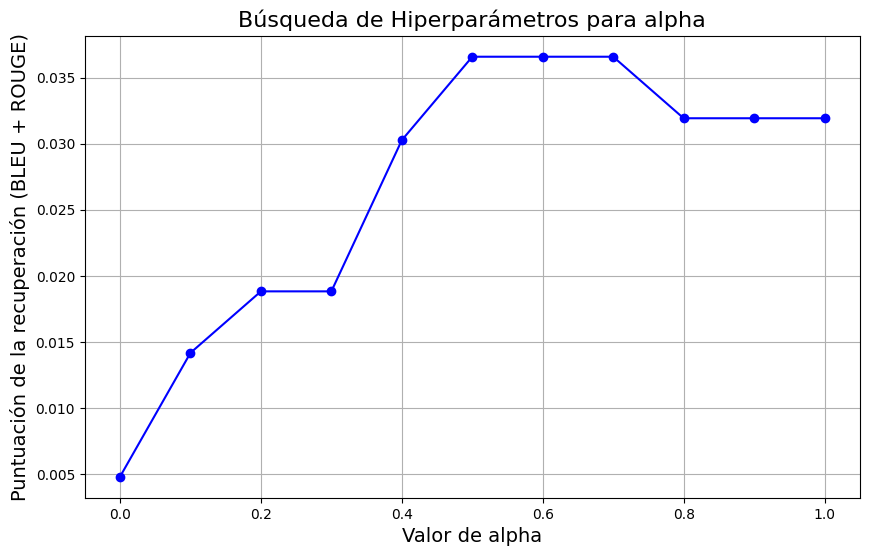

Mejor valor de alpha encontrado: 0.5


In [ ]:

import nltk
import numpy as np
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import sentence_bleu
from rouge_score import rouge_scorer

# Definir la función de búsqueda de hiperparámetros para el valor de alpha
def search_best_alpha(query, ground_truth, alphas=np.arange(0.0, 1.1, 0.1), top_k=5):
    # Almacenar los resultados de las puntuaciones para cada alpha
    alpha_scores = []

    # Probar diferentes valores de alpha
    for alpha in alphas:
        # Recuperar documentos usando el método híbrido con el valor de alpha
        print(f"Buscando para alpha = {alpha}")
        retrieved_docs = hybrid_retrieve(query, top_k=top_k, alpha=alpha)

        # Comparar la respuesta generada con la respuesta esperada (ground_truth)
        retrieved_answers = [doc["answer"] for doc in retrieved_docs]

        # Calcular BLEU y ROUGE para cada respuesta recuperada
        bleu_scores = []
        rouge_scores = []

        scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)

        for retrieved_answer in retrieved_answers:
            # BLEU
            bleu_scores.append(sentence_bleu([ground_truth[0].split()], retrieved_answer.split()))

            # ROUGE
            scores = scorer.score(ground_truth[0], retrieved_answer)
            rouge_scores.append(scores['rouge1'].fmeasure + scores['rougeL'].fmeasure)

        # Promediar las puntuaciones BLEU y ROUGE para este alpha
        avg_bleu = np.mean(bleu_scores)
        avg_rouge = np.mean(rouge_scores)

        # Usar el promedio de BLEU y ROUGE como score para este alpha
        alpha_scores.append((avg_bleu + avg_rouge) / 2)

    # Visualizar los resultados
    plt.figure(figsize=(10, 6))
    plt.plot(alphas, alpha_scores, marker='o', linestyle='-', color='b')
    plt.title('Búsqueda de Hiperparámetros para alpha', fontsize=16)
    plt.xlabel('Valor de alpha', fontsize=14)
    plt.ylabel('Puntuación de la recuperación (BLEU + ROUGE)', fontsize=14)
    plt.grid(True)
    plt.show()

    # Retornar el mejor valor de alpha
    best_alpha = alphas[np.argmax(alpha_scores)]
    print(f"Mejor valor de alpha encontrado: {best_alpha}")
    return best_alpha

# Suponiendo que tienes la consulta 'query' y la respuesta esperada 'ground_truth'
query = "¿Qué es la inmunodeficiencia de células T?"
ground_truth = ["Estos recursos abordan el diagnóstico o manejo de la inmunodeficiencia de células T."]  # Ejemplo de ground truth

# Ejecutar la búsqueda de hiperparámetros
best_alpha = search_best_alpha(query, ground_truth)

In [ ]:
query = "What is T-cell immunodeficiency?"
hybrid_retrieve(query, top_k=3, alpha=0.5)


[{'question_id': '0000968-5',
  'answer': 'These resources address the diagnosis or management of T-cell immunodeficiency, congenital alopecia, and nail dystrophy:  - Be The Match: What is a Bone Marrow Transplant?  - Genetic Testing Registry: T-cell immunodeficiency, congenital alopecia and nail dystrophy  - MedlinePlus Encyclopedia: Bone Marrow Transplant   These resources from MedlinePlus offer information about the diagnosis and management of various health conditions:  - Diagnostic Tests  - Drug Therapy  - Surgery and Rehabilitation  - Genetic Counseling   - Palliative Care',
  'score': np.float64(0.910937597068499)},
 {'question_id': '0000968-1',
  'answer': 'T-cell immunodeficiency, congenital alopecia, and nail dystrophy is a type of severe combined immunodeficiency (SCID), which is a group of disorders characterized by an almost total lack of immune protection from foreign invaders such as bacteria and viruses. People with this form of SCID are missing functional immune cells 

In [ ]:
from transformers import BartTokenizer, BartForConditionalGeneration

# Cargar el modelo BART
tokenizer = BartTokenizer.from_pretrained("facebook/bart-large")
bart_model = BartForConditionalGeneration.from_pretrained("facebook/bart-large")

# Función para generar respuestas con BART
def generate_answer_bart(query, retrieved_docs, max_input_length=1024, max_output_length=512):
    # Unir el contexto de los documentos recuperados
    context = " ".join([doc["answer"] for doc in retrieved_docs])


    # Crear input combinando pregunta y contexto directamente
    prompt = f"Answer the following question concisely based on the provided context:\nContext: {context}\nQuestion: {query}"

    # Tokenizar
    inputs = tokenizer(prompt, return_tensors="pt", max_length=max_input_length, truncation=True)

    # Generar salida
    outputs = bart_model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_length=max_output_length,
        num_beams=4,
        early_stopping=True
    )

    # Decodificar la respuesta
    return tokenizer.decode(outputs[0], skip_special_tokens=True)





tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.63k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

In [ ]:
query = "What are the symptoms of diabetes?"
retrieved_docs = hybrid_retrieve(query, top_k=3, alpha=0.5)
response = generate_answer_bart(query, retrieved_docs)
print("✅ Pregunta:", query)
print("🧠 Respuesta generada:", response)



✅ Pregunta: What are the symptoms of diabetes?
🧠 Respuesta generada: Answer the following question concisely based on the provided context:Context: Maternally inherited diabetes and deafness (MIDD) is a form of diabetes that is often accompanied by hearing loss, especially of high tones. In MIDD, the diabetes and hearing loss usually develop in mid-adulthood, although the age that they occur varies from childhood to late adulthood. Typically, hearing loss occurs before diabetes. The diabetes in MIDD is characterized by high blood sugar levels (hyperglycemia) resulting from a shortage of the hormone insulin, which regulates the amount of sugar in the blood. Individuals with MIDD also may experience muscle cramps or weakness, particularly during exercise; heart problems; kidney disease; and constipation.  There are two types of Wolfram syndrome with many overlapping features. The two types are differentiated by genetic cause.  In diabetes insipidus, the pituitary gland, which is located 